---

##  Summary: Combined vs Single2 Analysis

- Both **Combined** and **Single2** runs yield the **same detection scores** per DICOM.
- The **Combined** run acts as an aggregation of the individual Single runs.
- There is **no difference** in output between processing images together or separately.

>  **Study Folder Used:**  
> `2.25.58083309861372323384729383913137660594`  
> from  
> `/raid/data01/deephealth/dh_dh0new/2.25.58083309861372323384729383913137660594`

---


In [1]:
#Import Required Libraries
import os
import json


In [2]:
#Cell 2 – Define Paths to JSON Files
# Base directory for current test run
BASE_DIR = "/raid/mpsych/OMAMA/2025/PLAYGROUND/TEST04202025/OUT"

# Combined JSON
COMBINED_JSON = "/raid/mpsych/OMAMA/2025/PLAYGROUND/TEST04202025/OUT/combined/combined/results_full.json"

# Single2 run JSONs
SINGLE_01 = "/raid/mpsych/OMAMA/2025/PLAYGROUND/TEST04202025/OUT/single2/01/results_full.json"
SINGLE_02 = "/raid/mpsych/OMAMA/2025/PLAYGROUND/TEST04202025/OUT/single2/02/results_full.json"
SINGLE_03 = "/raid/mpsych/OMAMA/2025/PLAYGROUND/TEST04202025/OUT/single2/03/results_full.json"
SINGLE_04 = "/raid/mpsych/OMAMA/2025/PLAYGROUND/TEST04202025/OUT/single2/04/results_full.json"


In [12]:
 #Cell 3 – Load Combined JSON
    # Load combined run JSON
with open(COMBINED_JSON, "r") as f:
    combined_data = json.load(f)

print(" Combined JSON loaded")


 Combined JSON loaded


In [13]:
#Cell 4 – Load Single2 JSONs
# Load all 4 single2 JSONs
with open(SINGLE_01, "r") as f: single_01 = json.load(f)
with open(SINGLE_02, "r") as f: single_02 = json.load(f)
with open(SINGLE_03, "r") as f: single_03 = json.load(f)
with open(SINGLE_04, "r") as f: single_04 = json.load(f)

# Group into a list
single2_data = [single_01, single_02, single_03, single_04]
print(" Single2 JSONs loaded")


 Single2 JSONs loaded


In [14]:
print("")

In [15]:
# Combined scores
combined_total = combined_data["results"]["study_results"]["total"]["score"]
combined_L = combined_data["results"]["study_results"].get("L", {}).get("score")
combined_R = combined_data["results"]["study_results"].get("R", {}).get("score")

# Single2 scores from each subfolder
single2_01 = single2_data[0]["results"]["study_results"]
single2_02 = single2_data[1]["results"]["study_results"]
single2_03 = single2_data[2]["results"]["study_results"]
single2_04 = single2_data[3]["results"]["study_results"]

# Build simple list of rows
rows = [
    {"Run": "Combined", "Total": combined_total, "L": combined_L, "R": combined_R},
    {"Run": "single2/01", "Total": single2_01.get("total", {}).get("score"), "L": single2_01.get("L", {}).get("score"), "R": single2_01.get("R", {}).get("score")},
    {"Run": "single2/02", "Total": single2_02.get("total", {}).get("score"), "L": single2_02.get("L", {}).get("score"), "R": single2_02.get("R", {}).get("score")},
    {"Run": "single2/03", "Total": single2_03.get("total", {}).get("score"), "L": single2_03.get("L", {}).get("score"), "R": single2_03.get("R", {}).get("score")},
    {"Run": "single2/04", "Total": single2_04.get("total", {}).get("score"), "L": single2_04.get("L", {}).get("score"), "R": single2_04.get("R", {}).get("score")}
]

# Make the table
import pandas as pd
df_study_scores = pd.DataFrame(rows).round(4)
df_study_scores


,Run,Total,L,R
0,Combined,0.8239,0.3264,0.8239
1,single2/01,0.7997,NaN,0.7997
2,single2/02,0.8481,NaN,0.8481
3,single2/03,0.4130,0.4130,NaN
4,single2/04,0.2398,0.2398,NaN


In [16]:
# Extract Combined DICOM scores
combined_dicom = combined_data["results"]["dicom_results"]
rows = []

# Loop through each DICOM ID in combined
for dxm_id, results in combined_dicom.items():
    comb_score = max(d["score"] for d in results.get("none", []))
    
    # Look for a match in single2 subfolders
    single_score = None
    matching_folder = None
    for i, entry in enumerate(single2_data):
        dicom_results = entry["results"]["dicom_results"]
        if dxm_id in dicom_results:
            single_score = max(d["score"] for d in dicom_results[dxm_id].get("none", []))
            matching_folder = f"single2/0{i+1}"
            break
    
    delta = comb_score - single_score if single_score is not None else None
    rows.append({
        "DICOM ID": dxm_id,
        "Combined Score": round(comb_score, 4),
        "Single2 Run": matching_folder,
        "Single2 Score": round(single_score, 4) if single_score else None,
        "Δ (Combined − Single2)": round(delta, 4) if delta else None
    })

# Create table
df_dicom_comparison = pd.DataFrame(rows)
df_dicom_comparison


,DICOM ID,Combined Score,Single2 Run,Single2 Score,Δ (Combined − Single2)
0,2.25.72842288076787627397935409499732171821,0.4130,single2/03,0.4130,None
1,2.25.94798444938383228398686603731865913987,0.2398,single2/04,0.2398,None
2,2.25.202866200214167586134311633879833421698,0.7997,single2/01,0.7997,None
3,2.25.72104326632335992202064498528937913692,0.8481,single2/02,0.8481,None


###  Visualizing Predicted Most Malignant Images

This section displays the output images generated by DeepSight from both the **Combined** and **Single2** runs.

- **Combined Image** represents the model’s prediction when all 4 DICOMs were processed together.
- **Single2 Images (01–04)** represent predictions from the same 4 DICOMs, but processed individually.

 These visuals help verify if the model is producing consistent outputs across both methods.


 Combined Result Image:


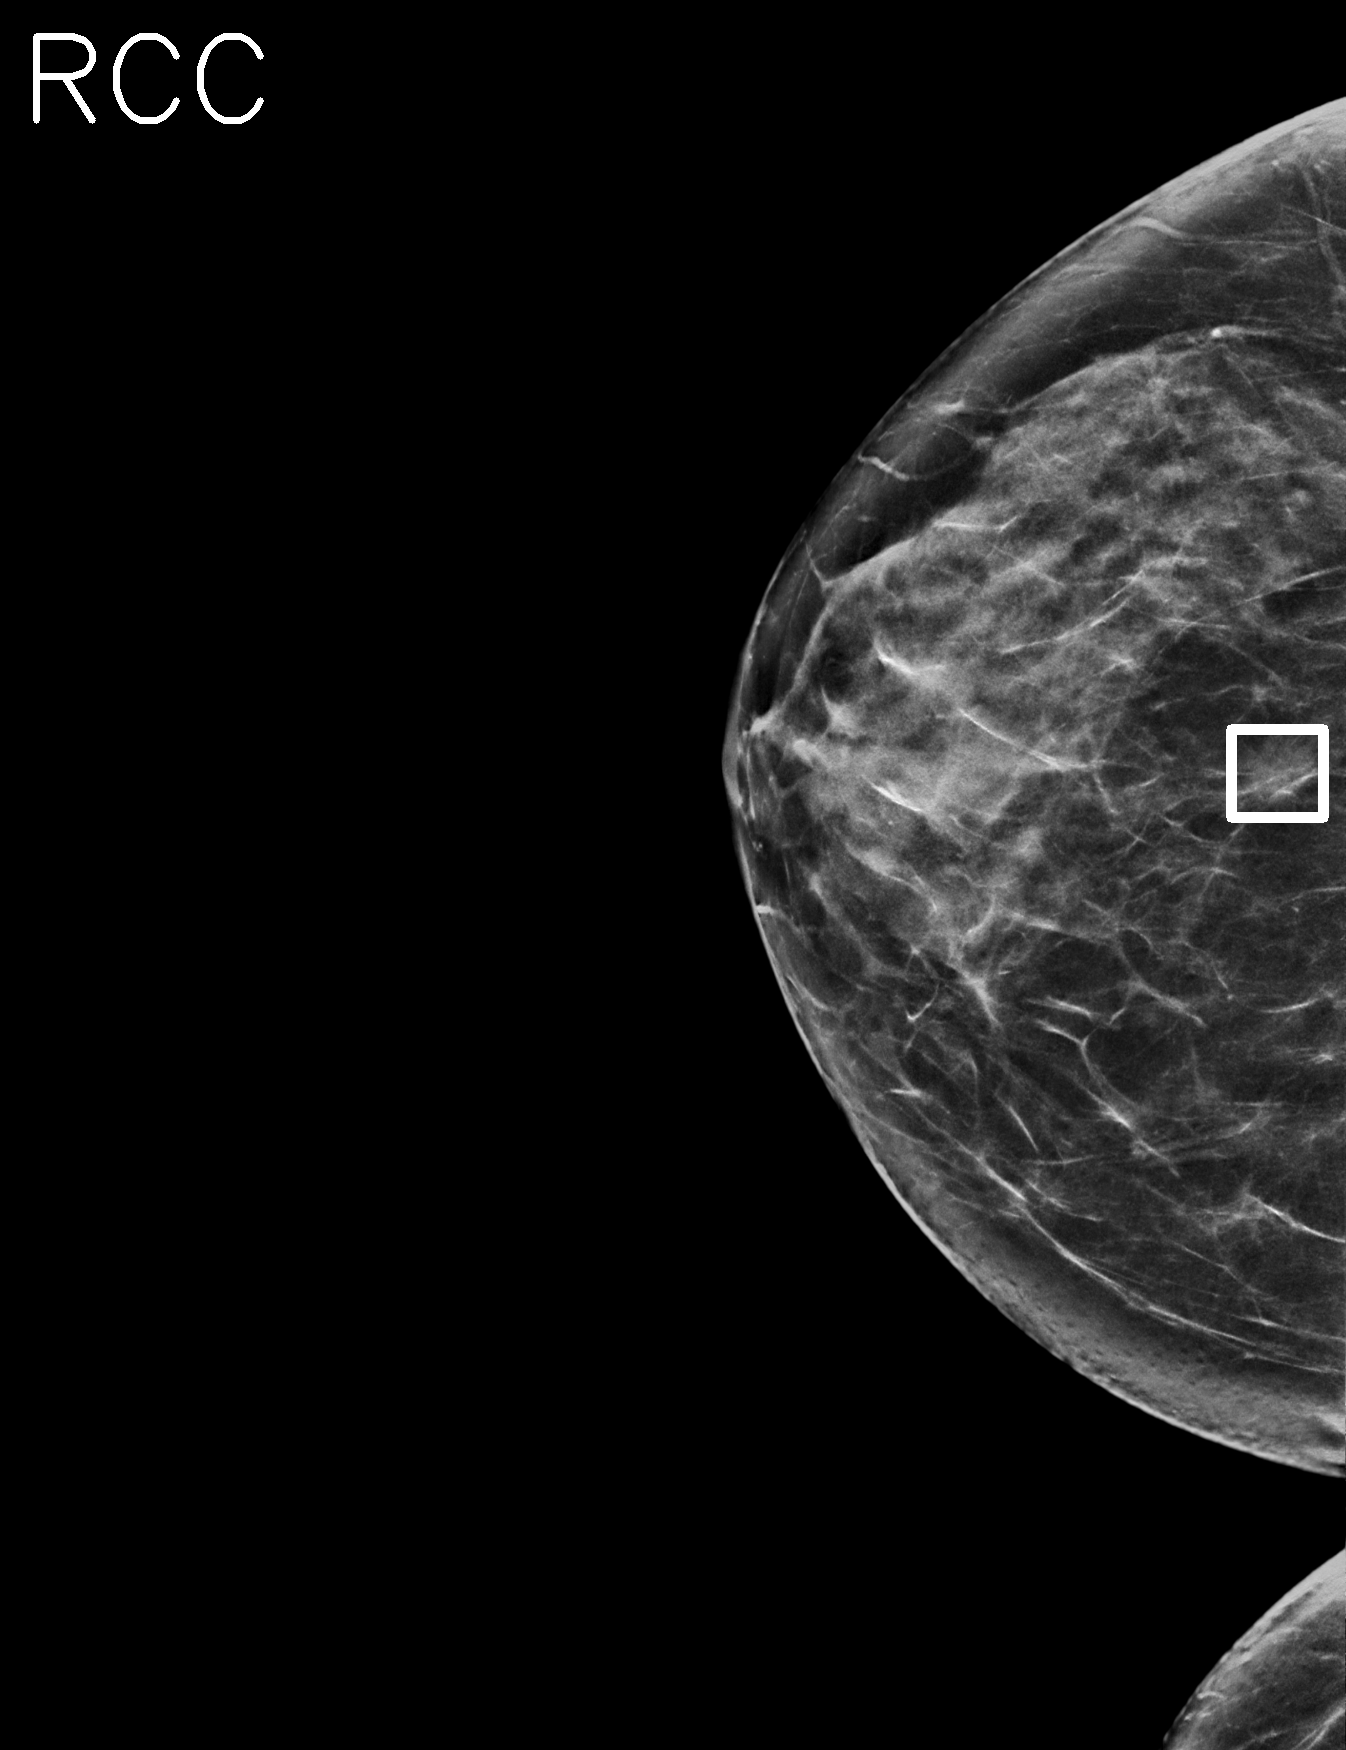

 Single2 Image 01:


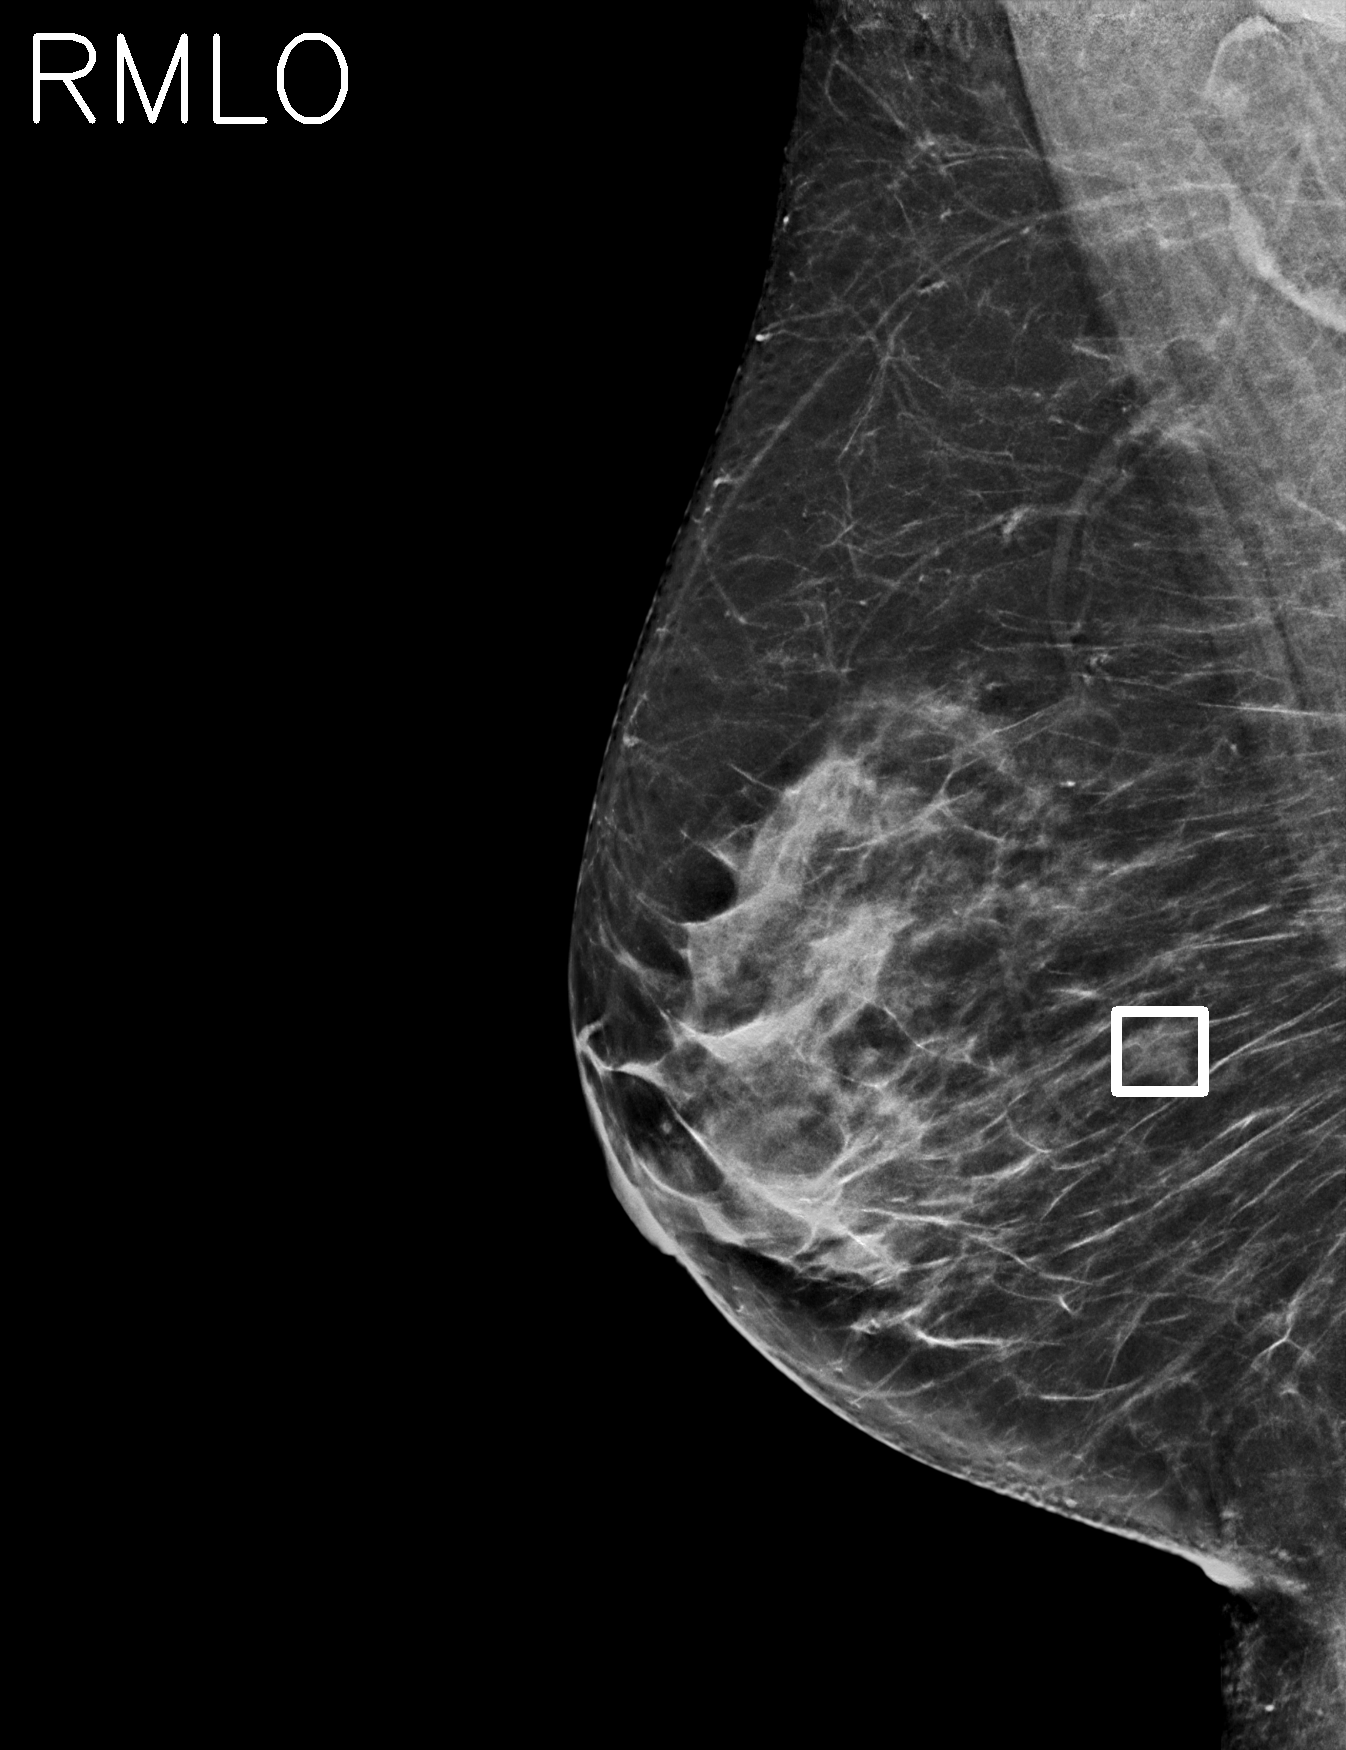

 Single2 Image 02:


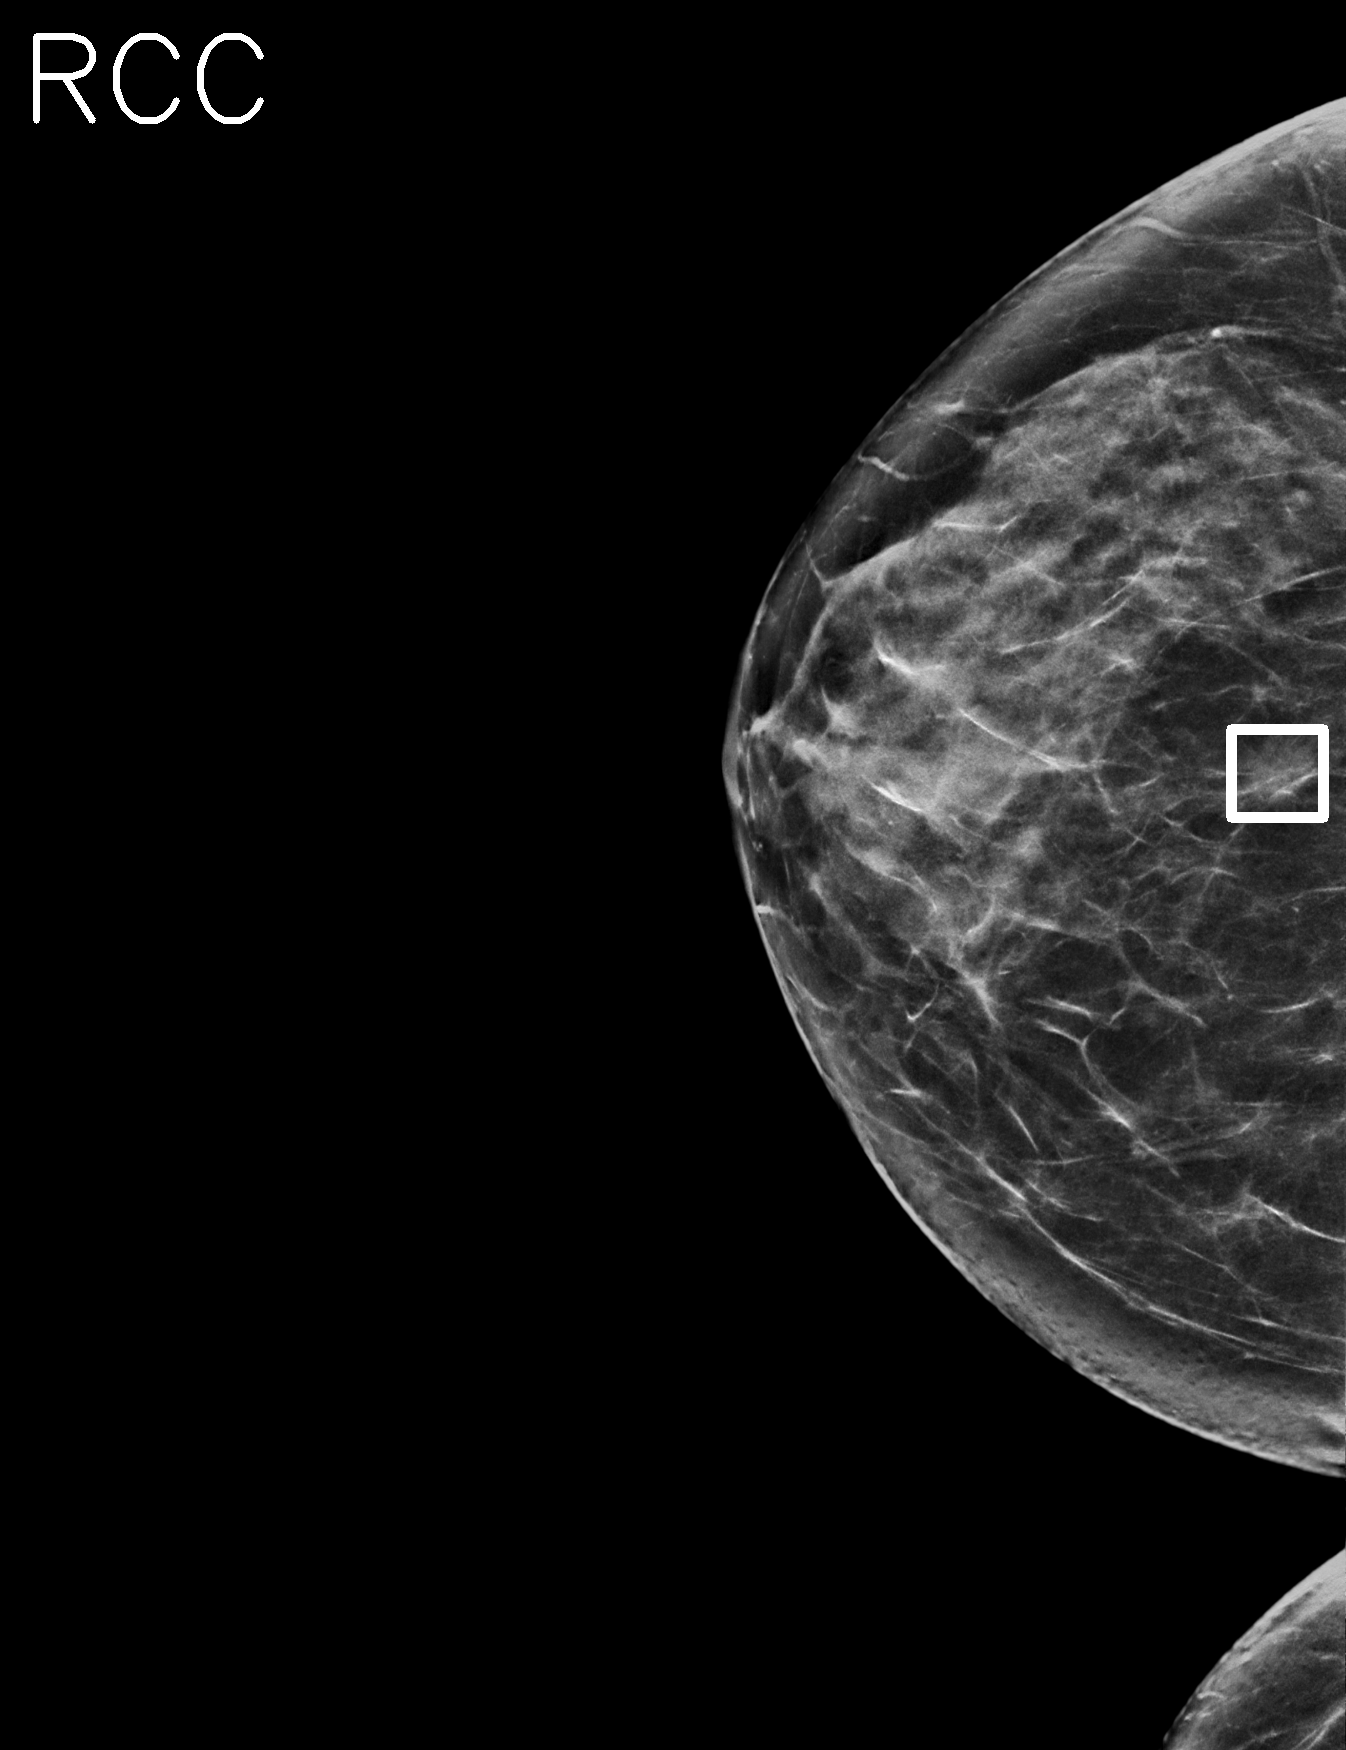

 Single2 Image 03:


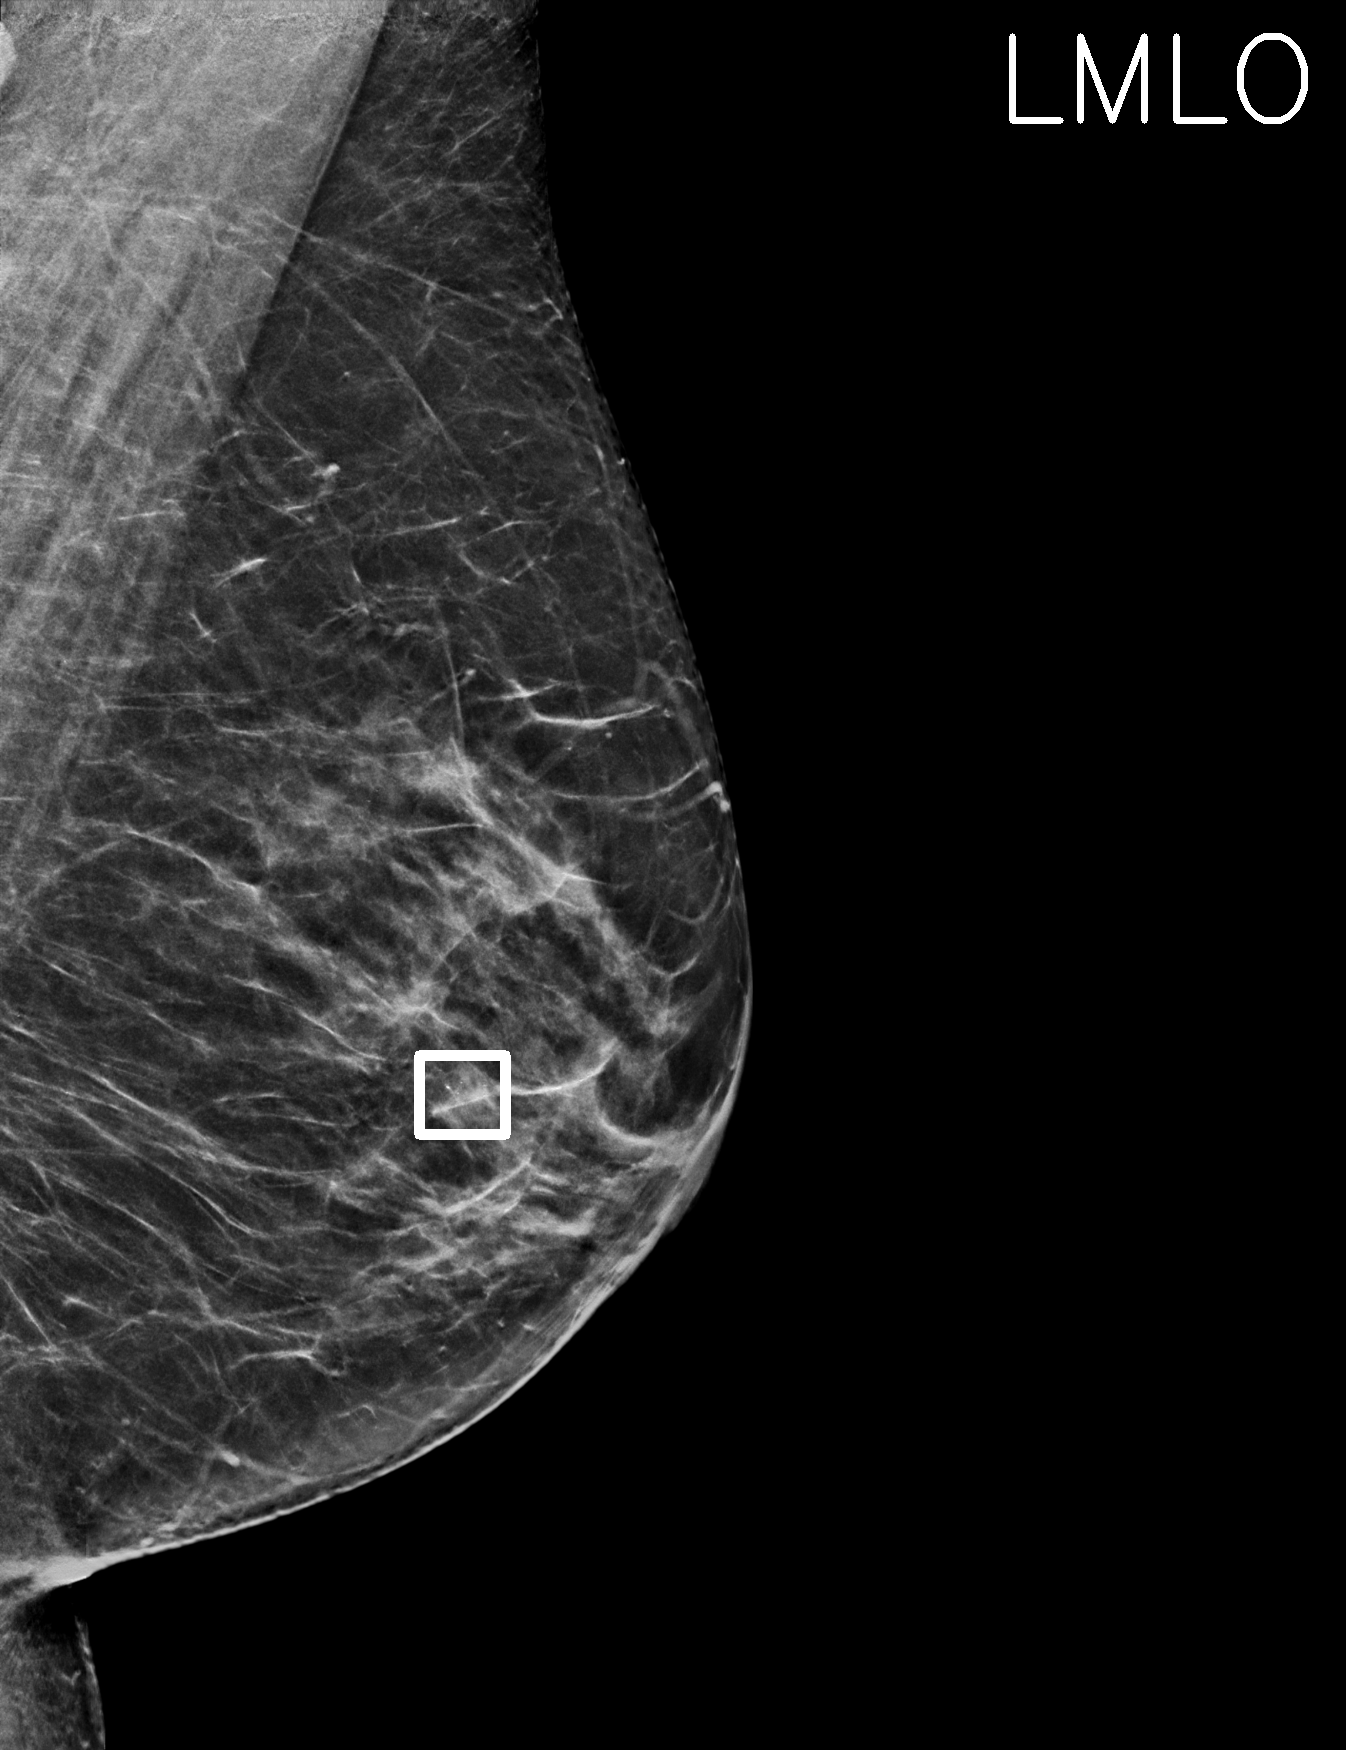

 Single2 Image 04:


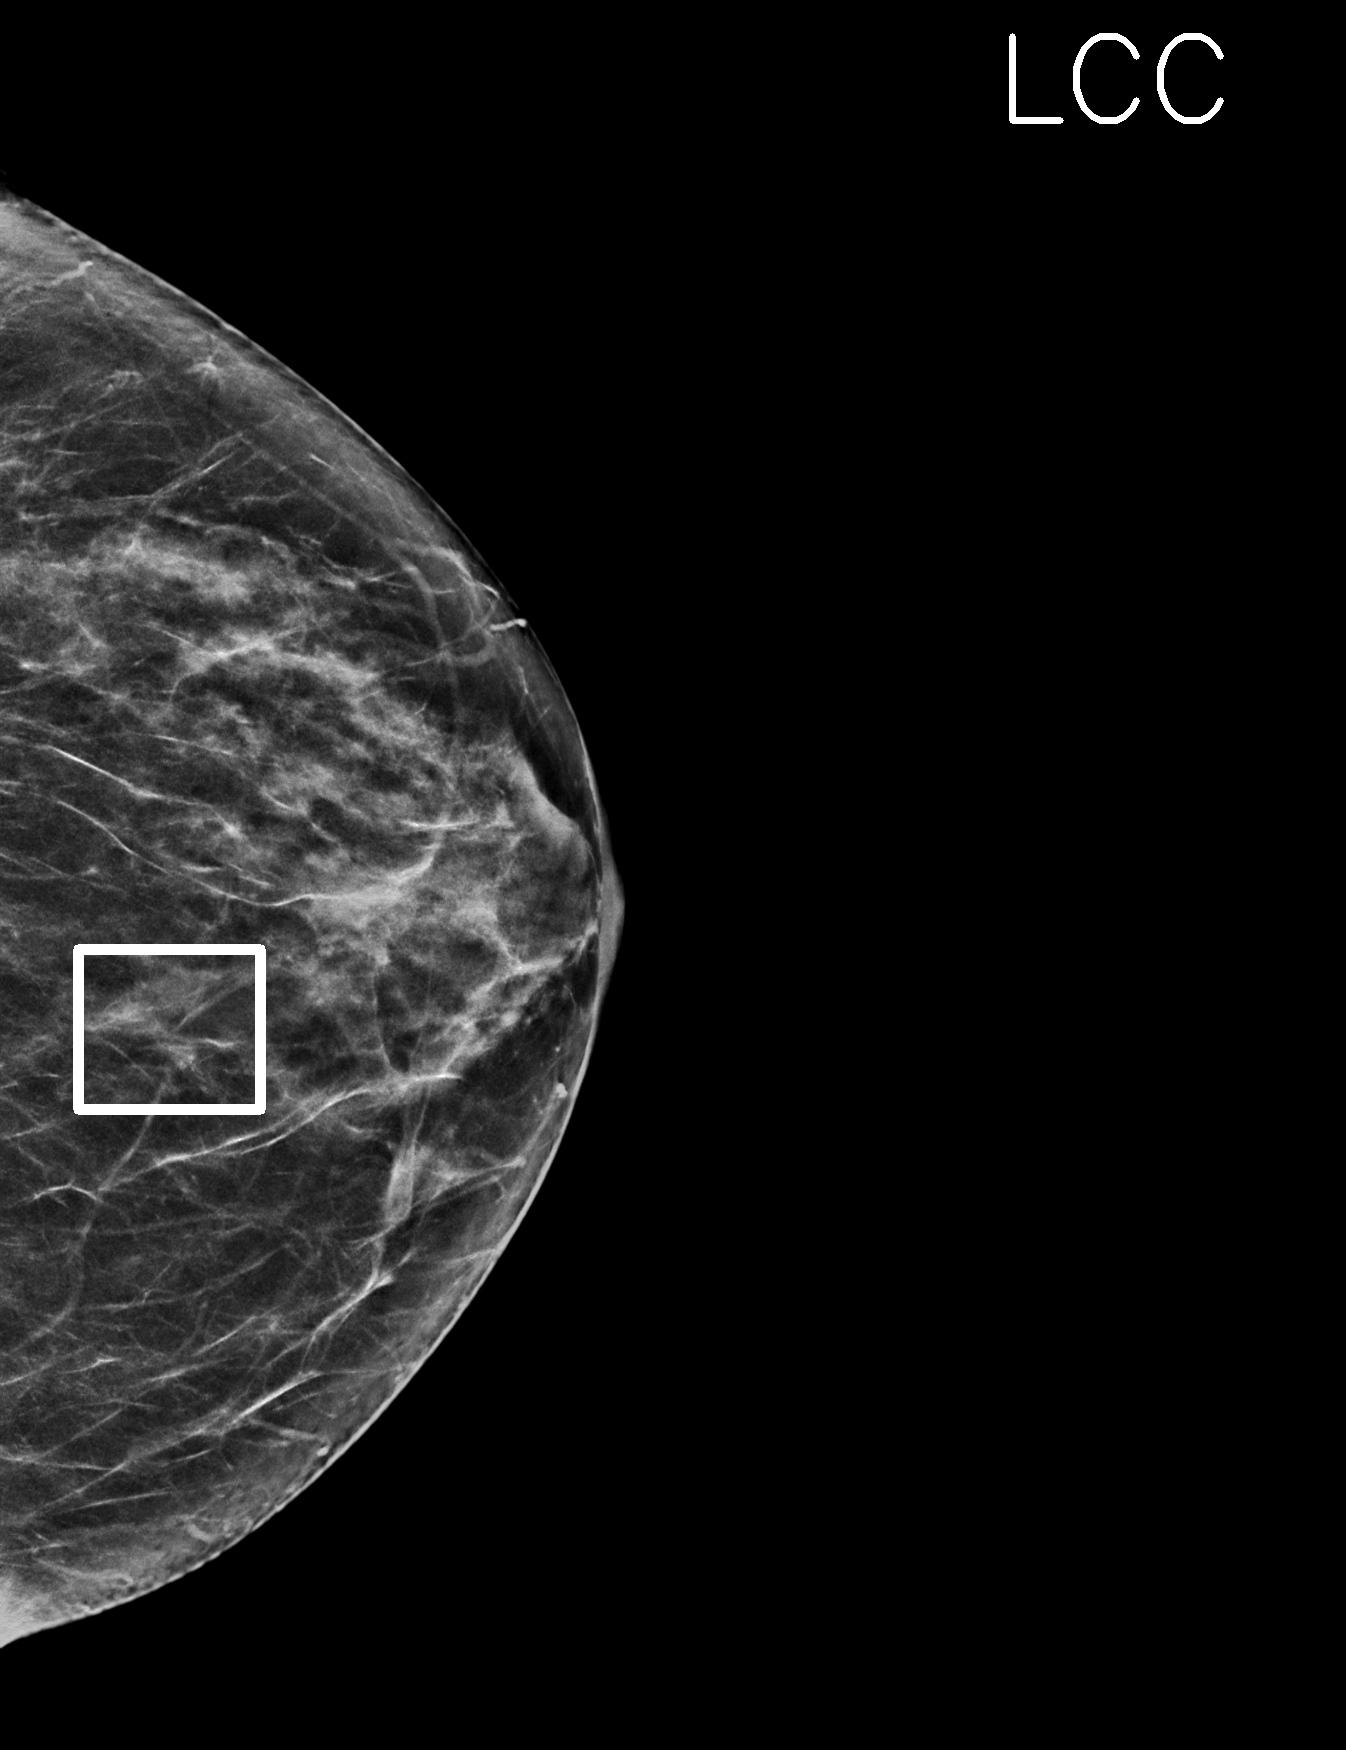

In [19]:
#  Display Combined and Single2 Images using PIL
from PIL import Image
from IPython.display import display

# Paths to images
combined_path = "/raid/mpsych/OMAMA/2025/PLAYGROUND/TEST04202025/OUT/combined/combined/DH_qa_mmaligImage_2.25.58083309861372323384729383913137660594.png"
single_paths = [
    "/raid/mpsych/OMAMA/2025/PLAYGROUND/TEST04202025/OUT/single2/01/DH_qa_mmaligImage_2.25.58083309861372323384729383913137660594.png",
    "/raid/mpsych/OMAMA/2025/PLAYGROUND/TEST04202025/OUT/single2/02/DH_qa_mmaligImage_2.25.58083309861372323384729383913137660594.png",
    "/raid/mpsych/OMAMA/2025/PLAYGROUND/TEST04202025/OUT/single2/03/DH_qa_mmaligImage_2.25.58083309861372323384729383913137660594.png",
    "/raid/mpsych/OMAMA/2025/PLAYGROUND/TEST04202025/OUT/single2/04/DH_qa_mmaligImage_2.25.58083309861372323384729383913137660594.png"
]

print(" Combined Result Image:")
display(Image.open(combined_path))

for i, spath in enumerate(single_paths, 1):
    print(f" Single2 Image {i:02d}:")
    display(Image.open(spath))
